# Variational Monte Carlo

In [10]:
!pip install qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.1/33.1 MB 33.1 MB/s eta 0:00:00


In [11]:
import numpy as np
import pylab as plt
import qutip
import scipy
import scipy.linalg
import scipy.stats as stats
from tqdm.notebook import tqdm
import time
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.animation as animation
from typing import NamedTuple
from scipy.integrate import tplquad
from numba import njit
def resetMe(keepList=[]):
    ll=%who_ls
    keepList=keepList+['FuncAnimation','HTML','resetMe','scipy','np','plt','math','jax','jnp','jit','grad','HTML','animation','qutip','animation','FuncAnimation','NamedTuple']
    for iiii in keepList:
        if iiii in ll:
            ll.remove(iiii)
    for iiii in ll:
        jjjj="^"+iiii+"$"
        %reset_selective -f {jjjj}
    ll=%who_ls
    plt.rcParams.update({"font.size": 14})
    return
#resetMe()
import datetime;datetime.datetime.now()
from functools import partial
#import jax as jnp

Our goal in this assignment is to understand molecules and binding.

## Exercise 1. Dihydrogen cation

We are going to start by looking at the Hydrogen H2 molecule but with only one electron - i.e. the dihydrogen cation.  In exercise 3, we will work our way up to standard H2 with two electrons.

### a.  A variational wave-function: attempt 1

In this assignment, we will allow our molecule be centered at the origin with protons at $\pm L/2 \hat{x}$.  We will start by working with $L=2$ Bohr radii.  

We now must decide on a variational wave-function.  A reasonable first guess is to assume the electron is spending time in between the two protons - i.e. centered at zero with some spread around it.  

We will begin by using the wave-function

$$
\Psi(r_1;\alpha) = \left(\frac{2\alpha}{\pi}\right)^{3/4} \exp[-\alpha(|r_1|^2 )]
$$

where $\alpha$ is a variational parameter.  To store this parameter, we will define a named tuple
```
class WavefunctionParams(NamedTuple):
  """Wavefunction Parameters"""
  alpha: float = 0.5
  beta: float = 0.0
params=WavefunctionParams(alpha=0.5)
```
which can then be accessed by `params.alpha`.  (`beta` will be used later - just ignore it for now)

Now write a function `Psi(e_pos,p_pos,params)` which takes the electron position, proton positions, and wave-function parameters and returns the wave-function amplitude.  Note that our current wave-function just ignores the proton positions.

Because the hydrogen atoms are lined up on the x-axis, plot the wave-function as a function of $x$ - i.e.  `xs=np.linspace(-3.1*L/2,3.1*L/2)`.  


 <div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (end)"></img><br></div>

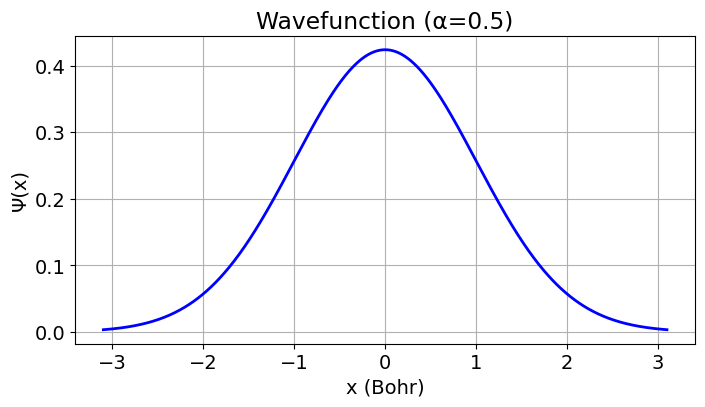

In [12]:
###ANSWER HERE
# Wavefunction parameter class
class WavefunctionParams(NamedTuple):
    alpha: float = 0.5
    beta: float = 0.0

# Global parameters for H₂⁺
L = 2.0
p_pos = np.array([[-L/2, 0, 0], [L/2, 0, 0]])
limit_r = 10.0
delta = 1e-5
plt.rcParams.update({"font.size": 14})

@njit
def Psi(e_pos, p_pos, params):
    alpha = params.alpha
    # Ensure e_pos is always 2D with (N, 3) shape for np.sum(axis=1)
    if e_pos.ndim == 1:
        e_pos = e_pos.reshape(1, -1)
    r_sq = np.sum(e_pos ** 2, axis=1)
    norm = (2 * alpha / np.pi) ** (3/4)
    return norm * np.exp(-alpha * r_sq)

# Plot wavefunction along x-axis
xs = np.linspace(-3.1*L/2, 3.1*L/2, 1000)
e_pos_plot = np.array([[x, 0, 0] for x in xs])
params = WavefunctionParams(alpha=0.5)
psi_vals = Psi(e_pos_plot, p_pos, params)

plt.figure(figsize=(8,4))
plt.plot(xs, psi_vals, 'b-', linewidth=2)
plt.xlabel('x (Bohr)')
plt.ylabel('Ψ(x)')
plt.title('Wavefunction (α=0.5)')
plt.grid(True)
plt.show()

 <div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>

### b. Evaluating the energy

To use the variational principle, we should compute the energy of the wave-function:


$$
E = \frac{\int \Psi^*(R) [H\Psi](R) dx dy dz }{\int \Psi^*(R) \Psi(R) dR }
$$

where $R=(x,y,z)$
which we will rewrite as

$$
E = \frac{\int |\Psi(R)|^2 \frac{[H\Psi](R)}{\Psi(R)} dx  }{\int |\Psi(R)|^2 dx} \equiv  \frac{\int |\Psi(R)|^2 E_L(R)}{\int |\Psi(x)|^2 dx}
$$

where the local energy

$$
E_L(R) = \frac{[H\Psi](R)}{\Psi(R)} = \frac{[-\nabla^2 \Psi /2+ V \Psi](R) }{\Psi(R)}
$$

where we are using the Hamiltonian

$$
H = \sum_i -\frac{1}{2} \nabla_i^2 + V(R)
$$

Let us start by writing a function `Laplacian(e_pos,p_pos,params,Psi ,delta=1e-5)` which takes the wave-function `Psi` and gives back the laplacian

$$
\nabla^2 \Psi = \frac{\partial^2}{\partial x^2}+ \frac{\partial^2}{\partial y^2}+ \frac{\partial^2}{\partial z^2}
$$


You can do this using the standard finite difference stencil for the Laplacian

$$
\frac{\partial^2 F}{\partial x^2} \approx \frac{F(x+\delta) +F(x-\delta) -2F(x)}{\delta^2}
 $$

We wish to evaluate $\nabla^2 \Psi / \Psi$ which we can do by evaluating
```
L=2.0
p_pos=np.array([[-L/2,0,0],[L/2,0,0]])
params=WavefunctionParams(alpha=0.5)
e_pos=np.array([[1.2,0.3,-0.4]])
print(Laplacian(e_pos, p_pos, params, Psi)/Psi(e_pos, p_pos, params))
```

and should get `-1.3099993792655844`

 <div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (end)"></img><br></div>

In [13]:
###ANSWER HERE
@njit
def Laplacian(e_pos, p_pos, params, Psi, delta=1e-5):
    lap = 0.0
    for dim in range(3):
        e_pos_plus = e_pos.copy()
        e_pos_plus[:, dim] += delta
        e_pos_minus = e_pos.copy()
        e_pos_minus[:, dim] -= delta
        # Psi returns a 1-element array, access the scalar value with [0]
        psi_plus = Psi(e_pos_plus, p_pos, params)[0]
        psi_minus = Psi(e_pos_minus, p_pos, params)[0]
        psi0 = Psi(e_pos, p_pos, params)[0]
        lap += (psi_plus + psi_minus - 2 * psi0) / delta**2
    return lap
e_pos_test = np.array([[1.2, 0.3, -0.4]])
print(Laplacian(e_pos_test, p_pos, WavefunctionParams(0.5), Psi)/Psi(e_pos_test,p_pos,WavefunctionParams(0.5))[0])

-1.3100009039904403


 <div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>

The next step is to get the potential piece of the energy

$$
\frac{V\Psi}{\Psi} = V(R) = -\sum_{Ie} \frac{1}{r_{Ie}} + \sum_{ee} \frac{1}{r_{ee}} + \sum_{II} \frac{1}{r_{II}}
$$  

where $I$ is the ion location and $e$ is the electron location. $r_{ab}$ stands for the distance $|r_a-r_b|$

For the dihydrogen cation there is no electron-electron term and so we can ignore that.   

Write a function `def VPsiOverPsi(e_pos,p_pos)` which returns this energy.
Again, you can test this by evaluating
```
p_pos=np.array([[-L/2,0,0],[L/2,0,0]])
params=WavefunctionParams(alpha=0.5)
e_pos=np.array([[1.2,0.3,-0.4]])
print(VPsiOverPsi(e_pos, p_pos))
```
and you should get
`-1.8001955889484549`

 <div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (end)"></img><br></div>

In [14]:
###ANSWER HERE
@njit
def VPsiOverPsi(e_pos, p_pos):
    # e_pos is expected to be a (1,3) array for a single electron in Ex1 context
    # Access the (3,) array for the single electron and remove 'axis' argument
    e_single = e_pos[0]
    r_Ie1 = np.linalg.norm(e_single - p_pos[0])
    r_Ie2 = np.linalg.norm(e_single - p_pos[1])
    r_II = np.linalg.norm(p_pos[0] - p_pos[1])
    V = -1.0 / r_Ie1 - 1.0 / r_Ie2 + 1.0 / r_II
    return V


# Test
print(VPsiOverPsi(e_pos_test, p_pos))

-1.8001955889484549


 <div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>

Finally, put it all together into a single function `LocalEnergy(e_pos, p_pos, params,Psi)` which computes the local energy. Make sure you remember the $-1/2$ in front of the Laplacian term.  

 <div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (end)"></img><br></div>

In [15]:
###ANSWER HERE
@njit
def LocalEnergy(e_pos, p_pos, params, Psi):
  # Psi returns a 1-element array, access the scalar value with [0]
  lap_over_psi = Laplacian(e_pos, p_pos, params, Psi) / Psi(e_pos, p_pos, params)[0]
  v = VPsiOverPsi(e_pos, p_pos)
  return -0.5 * lap_over_psi + v

 <div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>

### c. Computing the energy

Now that we have the wave-function `Psi` and the local energy `LocalEnergy` we should be able to compute the energy by doing the two integrals

$$
N = \int |\Psi(x,y,z)|^2 E_L(x,y,z) dx dy dz
$$

and

$$
D = \int |\Psi(x,y,z)|^2 dx dy dz
$$

and evaluating $N/D.$

These are both three-dimensional integrals and so it's possible to still compute them reasonably using a deterministic approach on a grid.   Later on in this assignment, we will have to switch to a Monte Carlo approach.  To compute an integral, we need to (for each integral)  to use the `integrate` function below and implement an appropriate `integrand` function (using the spherical coordinates Jacobian that we've started you with)

```
def integrand(r, theta, phi, p_pos, params):
    """
    Calculate the integrand for the expectation value in spherical coordinates.
    """
    x = r * np.sin(theta) * np.cos(phi)
    y = r * np.sin(theta) * np.sin(phi)
    z = r * np.cos(theta)
    e_pos = np.array([[x, y, z]])
    jacobian = r**2 * np.sin(theta)
    ### compute the other pieces of the integrand
    return jacobian * rest of integrand.

def integrate_spherical(p_pos,params,limit_r,integrand):
    integration_result, _ = tplquad(
                integrand,
                0, 2*np.pi,                # phi
                lambda phi: 0, lambda phi: np.pi,  # theta
                lambda phi, theta: 0, lambda phi, theta: limit_r , # r
                args=(p_pos, params,),epsabs=1.49e-02, epsrel=1.49e-02
    )
    return integration_result

alpha=0.5
L = 2.0
p_pos = np.array([[-L/2, 0, 0], [L/2, 0, 0]])
limit_r=10.0
params=WavefunctionParams(alpha=alpha)
N=integrate_spherical(p_pos,params,limit_r,integrand_energy_spherical)
D=integrate_spherical(p_pos,params,limit_r,integrand_norm_spherical)
print(N/D)
```

Using $\alpha=0.5$ and a sphere of `limit_r=10` compute the energy.  I get `-0.43539807117579543` for $N/D$.  Notice that if you have the normalization correct you should be getting $D=1$.

 <div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (end)"></img><br></div>

In [16]:
def integrate_spherical(p_pos, params, limit_r, integrand):
    integration_result, _ = tplquad(
                integrand,
                0, 2*np.pi,                # phi
                lambda phi: 0, lambda phi: np.pi,  # theta
                lambda phi, theta: 0, lambda phi, theta: limit_r , # r
                args=(p_pos, params,),epsabs=1.49e-02, epsrel=1.49e-02
    )
    return integration_result

@njit
def integrand_norm_spherical(r, theta, phi, p_pos, params):
    """Norm integrand: ∫ |Ψ|² dV (should give D ≈ 1)"""
    x = r * np.sin(theta) * np.cos(phi)
    y = r * np.sin(theta) * np.sin(phi)
    z = r * np.cos(theta)
    e_pos = np.array([[x, y, z]])
    jacobian = r**2 * np.sin(theta)
    # Psi returns a 1-element array, access the scalar value with [0]
    psi_val = Psi(e_pos, p_pos, params)[0]
    return jacobian * psi_val**2


@njit
def integrand_energy_spherical(r, theta, phi, p_pos, params):
    """Energy integrand: ∫ |Ψ|² E_L dV"""
    x = r * np.sin(theta) * np.cos(phi)
    y = r * np.sin(theta) * np.sin(phi)
    z = r * np.cos(theta)
    e_pos = np.array([[x, y, z]])
    jacobian = r**2 * np.sin(theta)
    # Psi returns a 1-element array, access the scalar value with [0]
    psi_val = Psi(e_pos, p_pos, params)[0]
    el = LocalEnergy(e_pos, p_pos, params, Psi)
    return jacobian * (psi_val**2) * el


# === Run the integrals ===
alpha = 0.5
L = 2.0
p_pos = np.array([[-L/2, 0, 0], [L/2, 0, 0]])
limit_r = 10.0
params = WavefunctionParams(alpha=alpha)

N = integrate_spherical(p_pos, params, limit_r, integrand_energy_spherical)
D = integrate_spherical(p_pos, params, limit_r, integrand_norm_spherical)

print(N / D)
print("D (should be ~1):", D)

/usr/local/lib/python3.12/dist-packages/scipy/integrate/_quadpack_py.py:1264: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


-0.435396785259841
D (should be ~1): 1.0000000008162848


 <div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>

### d. Optimizing the energy

Now, let's do this again looping over all  `alpha=np.linspace(0.1,0.5,20)`.   We are looking for the variational parameter that makes this wave-function the smallest.  Plot energy vs. $\alpha$ . Fit a parobola to the function somewhere near the minima (`poly=np.polyfit(x,y,2)`)and predict what the best $\alpha$ is.  Compute the energy again with this $\alpha$ to get the lowest energy giving the variational space of this wave-function.

 <div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (end)"></img><br></div>

/usr/local/lib/python3.12/dist-packages/scipy/integrate/_quadpack_py.py:1264: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


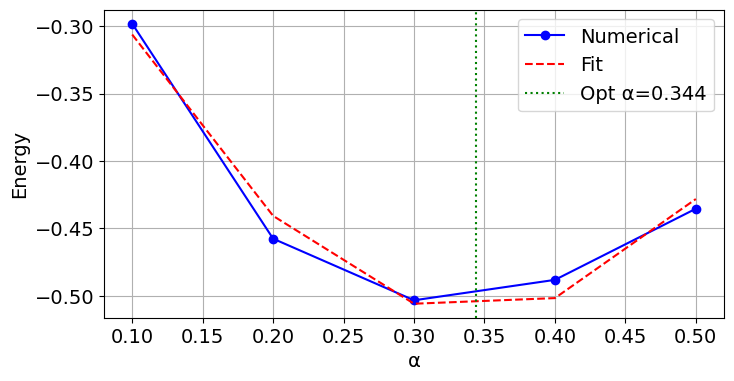

In [17]:
###ANSWER HERE
alphas = np.linspace(0.1,0.5,5) # Reduced from 20 to 5 for faster execution
energies = []
# Reducing limit_r for faster execution in this optimization step
original_limit_r = limit_r # Store original limit_r if needed later
limit_r = 5.0 # Temporarily reduce integration limit

for a in alphas:
    params = WavefunctionParams(a)
    N = integrate_spherical(p_pos,params,limit_r,integrand_energy_spherical)
    D = integrate_spherical(p_pos,params,limit_r,integrand_norm_spherical)
    energies.append(N/D)

limit_r = original_limit_r # Restore original limit_r

# Parabolic fit
poly = np.polyfit(alphas, energies, 2)
alpha_opt = -poly[1]/(2*poly[0])
energy_opt = np.polyval(poly, alpha_opt)

# Plot
plt.figure(figsize=(8,4))
plt.plot(alphas, energies, 'bo-', label='Numerical')
plt.plot(alphas, np.polyval(poly,alphas), 'r--', label='Fit')
plt.axvline(alpha_opt, c='g', ls=':', label=f'Opt α={alpha_opt:.3f}')
plt.xlabel('α'), plt.ylabel('Energy'), plt.legend(), plt.grid(True)
plt.show()

In [18]:
###ANSWER HERE

 <div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>

Finally plot out the wave-function on the x-axis (in the direction of the two protons) for the optimal $\alpha$.

 <div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (end)"></img><br></div>

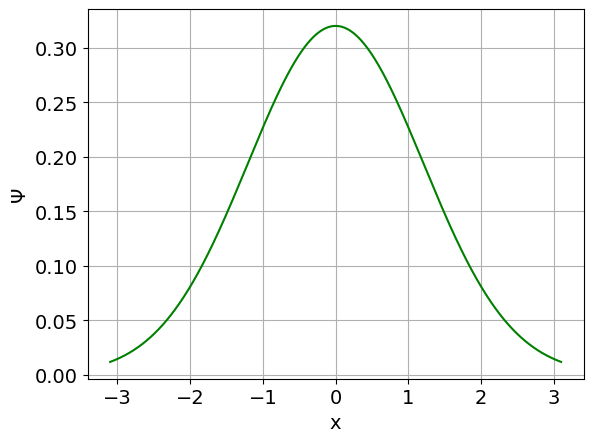

Opt α=0.3440, Opt Energy=-0.512607


In [19]:
###ANSWER HERE
# Optimal wavefunction
xs = np.linspace(-3.1*L/2,3.1*L/2,1000)
psi_opt = Psi(np.array([[x,0,0] for x in xs]), p_pos, WavefunctionParams(alpha_opt))
plt.plot(xs, psi_opt, 'g-'), plt.xlabel('x'), plt.ylabel('Ψ'), plt.grid(True), plt.show()

print(f"Opt α={alpha_opt:.4f}, Opt Energy={energy_opt:.6f}")

 <div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>

## Exercise 2. Variational Monte Carlo

### a. Variational Monte Carlo

So far we've evaluated our wave-function using quadrature.  This works "ok" when you have one electron because you can afford to make a three-dimensional grid.  Eventually, though, we will need to transition to Monte Carlo to evaluate our wave-functions;  for example, to do the Hydrogen molecule with two electrons (as it would typically have), then we would need to do a six-dimensional integration.  

 In this exercise we will still work with the dihydrogen cation but switch over to variational Monte Carlo and make sure that we get the same energy.

The steps of variational Monte Carlo:

* For many `sweeps`:
    * For 10 steps per sweep:
        * Evaluate the old wavefunction amplitude `wf_old=Psi(e_pos,p_pos,params)`
        * Change the location of the electron by a random gaussian `np.random.randn(3)*1.0`
        * Evaluate the new wavefunction amplitude `wf_new=Psi(e_pos,p_pos,params)` at this new position
        * If `(wf_new/wf_old)^2` is greater then a random number selected between 0 and 1 (`np.random.rand()`) accept and keep the new positions.  Otherwise revert to the old positions.
    * Add the current local energy to an energy list and the current location to a location list.

Once this is done you can average the local energy list (ignoring the first few entries where the Monte Carlo was still equilibrating).    Write a function `MonteCarlo(p_pos,params,Psi,sweeps)` which performs this Variational Monte Carlo and returns the energies, acceptance ratio of your moves, and locations.

Call your `MonteCarlo` function for our wave-function at $\alpha=0.5$ using 10,000 sweeps. You can compute an error bar by doing `error_energy=np.std(energies[l:])/np.sqrt(len(energies[l:]))` where `l=100` is a number of sweeps to ignore as the transient. Check that you are within 1-2 error bars of the value you computed above in exercise 1.

Also plot the energy as a function of sweeps and plot a histogram of the energies.  You should notice that it is very spikey and the histogram has a long tail to the left.

 <div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (end)"></img><br></div>

VMC Energy: -0.430822±0.002097, Accept: 0.308


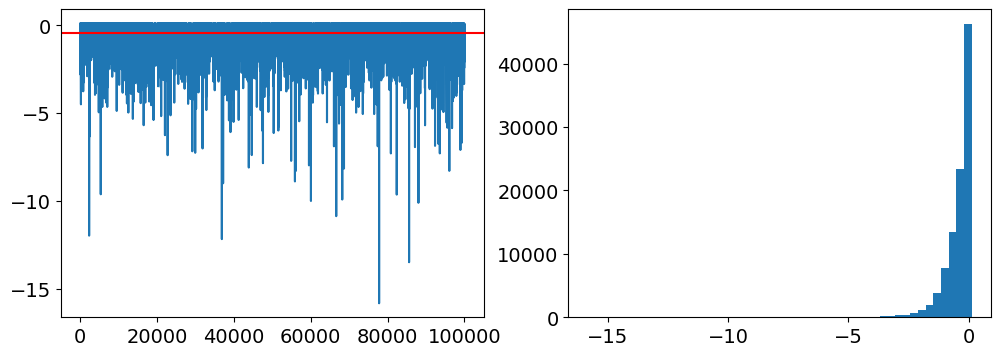

In [20]:
###ANSWER HERE
def MonteCarlo(p_pos, params, Psi, sweeps=10000, step_size=1.0):
    e_pos = np.array([[0.,0.,0.]])
    energies, accept = [], 0
    total = sweeps*10
    for _ in range(sweeps):
        for __ in range(10):
            wf_old = Psi(e_pos,p_pos,params)[0]
            e_new = e_pos + np.random.randn(3)*step_size
            wf_new = Psi(e_new,p_pos,params)[0]
            if np.random.rand() < (wf_new/wf_old)**2:
                e_pos = e_new
                accept +=1
            energies.append(LocalEnergy(e_pos,p_pos,params,Psi))
    return np.array(energies), accept/total

# Run VMC
ens, acc = MonteCarlo(p_pos, WavefunctionParams(0.5), Psi)
mean = np.mean(ens[100:])
err = np.std(ens[100:])/np.sqrt(len(ens[100:]))
print(f"VMC Energy: {mean:.6f}±{err:.6f}, Accept: {acc:.3f}")

# Plot
plt.figure(figsize=(12,4))
plt.subplot(121), plt.plot(ens), plt.axhline(mean,c='r')
plt.subplot(122), plt.hist(ens[100:],bins=50)
plt.show()

 <div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>

### b.  Energy as a function of $\alpha$

Now go ahead and produce the energy as a function of $\alpha$ for `alphas=np.linspace(0.01,0.5,40)`.  Check that your data matches the data from above.  Run for 20,000 sweeps for each point and only average your energy after ignoring the first 100 points (e.g. `np.mean(energies[100:])` )

 <div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (end)"></img><br></div>

  0%|          | 0/40 [00:00<?, ?it/s]

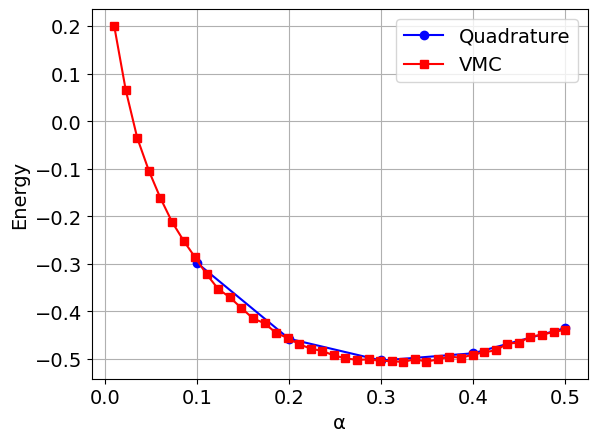

(Text(0.5, 29.0, 'α'),
 Text(29.0, 0.5, 'Energy'),
 None,
 None)

In [21]:
###ANSWER HERE
alphas_vmc = np.linspace(0.01,0.5,40)
ens_vmc = []
for a in tqdm(alphas_vmc):
    e,_ = MonteCarlo(p_pos,WavefunctionParams(a),Psi,sweeps=20000)
    ens_vmc.append(np.mean(e[100:]))

plt.plot(alphas,energies,'bo-',label='Quadrature')
plt.plot(alphas_vmc,ens_vmc,'rs-',label='VMC')
plt.xlabel('α'), plt.ylabel('Energy'), plt.legend(), plt.grid(True), plt.show()

In [22]:
###ANSWER HERE

 <div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>

### c.  A problematic wave-function

We would like to make our wave-function better.   One property of the exact wave-function is that the local energy $E_L(x,y,z) \equiv [H(\Psi_0)](x,y,z)/\Psi_0(x,y,z)$  is the same (a constant) no matter what coordinate we are evaluating it at.  But we saw that our variational wave-function is very far from this limit.  In fact, the spikiness and broad histogram of the local energy tells us that there are lots of configurations which are very different.  We'd like to diagnose what is causing this extreme spikiness so we can work on making it better.

To do this, let us look at the local energy explicitly.  Plot the local energy, the kinetic piece of the local energy and the potential piece of the local energy as a function of `xs=np.linspace(-2,2,1000)` all on the same plot .  Pay special attention to where the electron and protons are at the same position.  



 <div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (end)"></img><br></div>

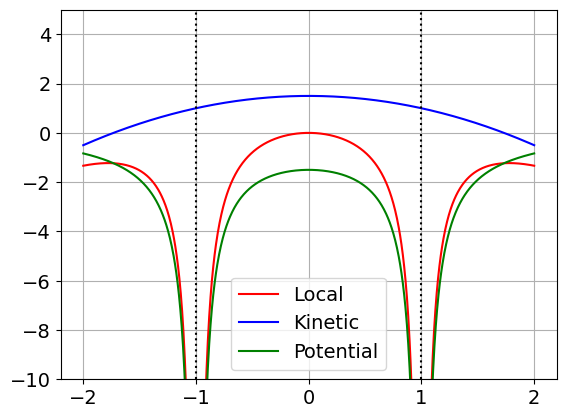

(<matplotlib.lines.Line2D at 0x7b7142cca480>,
 (-10.0, 5.0),
 None,
 None)

In [23]:
###ANSWER HERE
xs = np.linspace(-2,2,1000)
el,kin,pot = [],[],[]
for x in xs:
    e = np.array([[x,0,0]])
    l = Laplacian(e,p_pos,WavefunctionParams(0.5),Psi)
    psi = Psi(e,p_pos,WavefunctionParams(0.5))[0]
    k = -0.5*(l/psi)
    p = VPsiOverPsi(e,p_pos)
    el.append(k+p), kin.append(k), pot.append(p)

plt.plot(xs,el,'r-',label='Local'), plt.plot(xs,kin,'b-',label='Kinetic'), plt.plot(xs,pot,'g-',label='Potential')
plt.axvline(-1,c='k',ls=':'), plt.axvline(1,c='k',ls=':'), plt.ylim(-10,5), plt.legend(), plt.grid(True), plt.show()

 <div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>

### d. A Jastrow

What you should have seen in the last part is that the local energy gets very negative as the electron approaches the protons.  This is happening because the potential piece is getting negative and the kinetic piece is not cancelling it out.  To fix this, we can enforce a cusp condition on our wave-function by adding a Jastrow factor writing a new wave-function as

$$
\Psi_{new}(r;\alpha,\beta)=\Psi_{old}(r;\alpha)\exp[J_{ep}(r;\beta)]
$$

where

$$
J_{ep}=-\frac{a_{ep}|r_i-I_j|} {1+b_{ep}|r_i-I_j|}
$$

where $a_{ep}=1$ are chosen to satisfy the electron-proton cusp conditions, respectively.

The parameter $\beta$ gives additional freedom through the relations,

$$
b_{ep} = \left( \frac{a_{ep}}{\beta}\right)^{1/2}
$$

Implement this Jastrow function (say using $\beta =0.1$) and again plot the local energy (with the kinetic and potential pieces). What do you notice that is different?




 <div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (end)"></img><br></div>

In [24]:
###ANSWER HERE
from numba import njit

@njit
def Jastrow_ep(e_pos, p_pos, beta):
    a = 1.0
    b = np.sqrt(a / beta)
    j_sum = 0.0
    # e_pos is (1, 3)
    for i in range(p_pos.shape[0]):
        dist = np.linalg.norm(e_pos[0] - p_pos[i])
        j_sum += -a * dist / (1 + b * dist)
    return j_sum

@njit
def Psi_Jastrow(e_pos, p_pos, params):
    # Psi returns a 1-element array, access the scalar value with [0]
    psi0 = Psi(e_pos, p_pos, params)[0]
    j_val = Jastrow_ep(e_pos, p_pos, params.beta)
    return np.array([psi0 * np.exp(j_val)])

# Plotting local energy components with Jastrow factor
xs = np.linspace(-2, 2, 1000)
el_j, kin_j, pot_j = [], [], []
params_j = WavefunctionParams(alpha=0.5, beta=0.1)

for x in xs:
    e = np.array([[x, 0, 0]])
    psi_val = Psi_Jastrow(e, p_pos, params_j)[0]
    lap = Laplacian(e, p_pos, params_j, Psi_Jastrow)
    k = -0.5 * (lap / psi_val)
    p = VPsiOverPsi(e, p_pos)
    el_j.append(k + p)
    kin_j.append(k)
    pot_j.append(p)

plt.figure(figsize=(10, 6))
plt.plot(xs, el_j, 'r-', label='Local Energy (Jastrow)')
plt.plot(xs, kin_j, 'b-', label='Kinetic (Jastrow)')
plt.plot(xs, pot_j, 'g-', label='Potential (Jastrow)')
plt.axvline(-1, color='k', linestyle='--')
plt.axvline(1, color='k', linestyle='--')
plt.ylim(-5, 5)
plt.xlabel('x (Bohr)')
plt.ylabel('Energy')
plt.legend()
plt.title('Energy Components with Jastrow Factor (β=0.1)')
plt.grid(True)
plt.show()

### e. Using our Jastrow

Now we are going to go ahead and use our Jastrow factor.  Again, compute the value of our wavefunction with parameters $\alpha=0.5$ and $\beta=0.1$  Plot the local energy as a function of Monte Carlo step and the histogram.  What do you notice now that is different from the earlier plots without the Jastrow?

 <div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (end)"></img><br></div>

Jastrow VMC Energy (beta=0.1): -0.447816 +/- 0.001889
Acceptance Ratio: 0.301


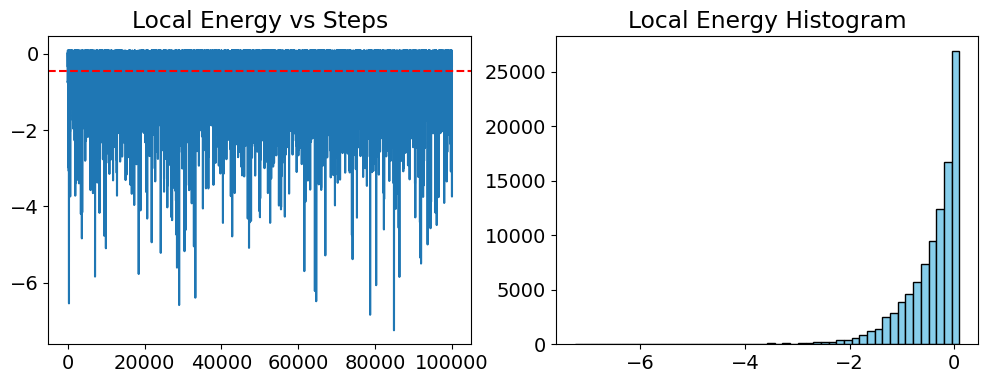

In [25]:
###ANSWER HERE
from numba import njit
import numpy as np
import matplotlib.pyplot as plt

# Defining dependencies for standalone execution
from typing import NamedTuple
class WavefunctionParams(NamedTuple):
    alpha: float = 0.5
    beta: float = 0.0

L = 2.0
p_pos = np.array([[-L/2, 0, 0], [L/2, 0, 0]])

@njit
def Psi(e_pos, p_pos, params):
    alpha = params.alpha
    r_sq = np.sum(e_pos**2)
    norm = (2 * alpha / np.pi)**(0.75)
    return np.array([norm * np.exp(-alpha * r_sq)])

@njit
def Jastrow_ep(e_pos, p_pos, beta):
    a = 1.0
    b = np.sqrt(a / beta)
    j_sum = 0.0
    for i in range(p_pos.shape[0]):
        dist = np.linalg.norm(e_pos[0] - p_pos[i])
        j_sum += -a * dist / (1 + b * dist)
    return j_sum

@njit
def Psi_Jastrow(e_pos, p_pos, params):
    psi0 = Psi(e_pos, p_pos, params)[0]
    j_val = Jastrow_ep(e_pos, p_pos, params.beta)
    return np.array([psi0 * np.exp(j_val)])

@njit
def Laplacian(e_pos, p_pos, params, Psi_func, delta=1e-5):
    lap = 0.0
    psi0 = Psi_func(e_pos, p_pos, params)[0]
    for dim in range(3):
        e_plus = e_pos.copy()
        e_plus[0, dim] += delta
        e_minus = e_pos.copy()
        e_minus[0, dim] -= delta
        psi_plus = Psi_func(e_plus, p_pos, params)[0]
        psi_minus = Psi_func(e_minus, p_pos, params)[0]
        lap += (psi_plus + psi_minus - 2 * psi0) / delta**2
    return lap

@njit
def VPsiOverPsi(e_pos, p_pos):
    e_single = e_pos[0]
    r_Ie1 = np.linalg.norm(e_single - p_pos[0])
    r_Ie2 = np.linalg.norm(e_single - p_pos[1])
    r_II = np.linalg.norm(p_pos[0] - p_pos[1])
    return -1.0 / r_Ie1 - 1.0 / r_Ie2 + 1.0 / r_II

@njit
def LocalEnergy(e_pos, p_pos, params, Psi_func):
    lap_over_psi = Laplacian(e_pos, p_pos, params, Psi_func) / Psi_func(e_pos, p_pos, params)[0]
    return -0.5 * lap_over_psi + VPsiOverPsi(e_pos, p_pos)

@njit
def MonteCarlo(p_pos, params, Psi_func, sweeps=10000, step_size=1.0):
    e_pos = np.zeros((1, 3))
    energies = np.zeros(sweeps * 10)
    accept = 0
    count = 0
    for _ in range(sweeps):
        for __ in range(10):
            wf_old = Psi_func(e_pos, p_pos, params)[0]
            e_new = e_pos + np.random.randn(1, 3) * step_size
            wf_new = Psi_func(e_new, p_pos, params)[0]
            if np.random.rand() < (wf_new / wf_old)**2:
                e_pos = e_new
                accept += 1
            energies[count] = LocalEnergy(e_pos, p_pos, params, Psi_func)
            count += 1
    return energies, accept / (sweeps * 10)

# Run VMC with Jastrow factor
params_j = WavefunctionParams(alpha=0.5, beta=0.1)
ens_j, acc_j = MonteCarlo(p_pos, params_j, Psi_Jastrow, sweeps=10000)

mean_j = np.mean(ens_j[1000:])
err_j = np.std(ens_j[1000:]) / np.sqrt(len(ens_j[1000:]))

print(f"Jastrow VMC Energy (beta=0.1): {mean_j:.6f} +/- {err_j:.6f}")
print(f"Acceptance Ratio: {acc_j:.3f}")

plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.plot(ens_j)
plt.axhline(mean_j, color='r', linestyle='--')
plt.title('Local Energy vs Steps')
plt.subplot(122)
plt.hist(ens_j[1000:], bins=50, color='skyblue', edgecolor='black')
plt.title('Local Energy Histogram')
plt.show()

 <div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>

### f.  Getting the energy again

Now we want to find the best energy again for this bond-length.  This time we have to search over the variational parameters $\alpha$ and $\beta$.  Using `alphas=np.linspace(0.01,0.5,20)` and `betas=np.linspace(5.0,15.0,20)` search over the relevant space.   Store the results in a 2D array `all_energies=np.zeros((20,20))`.  I am using 1000 sweeps per simulation and ignoring the first 100 sweeps to evaluate the energy (treating this as a transient).  

Plot the following things:

**(1) For every `beta` plot a line which is the energy versus `alpha` for that `beta`**

I did something like
```python
for i,beta in enumerate(betas):
    plt.plot(alphas,allEnergies[i,:],label='beta='+str(beta))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('alpha')
plt.ylabel('Energy')    
plt.show()
```

**(2) Plot the 2D energies:**

I did this using
```python
plt.imshow(allEnergies,origin='lower',aspect='auto',cmap='hot',extent=[alphas[0],alphas[-1],betas[0],betas[-1]])
plt.colorbar(label='Energy')
plt.xlabel('Alpha')
plt.ylabel('Beta')
plt.title('Energy vs Alpha and Beta')
plt.show()
```
**(3) Finally take the lowest energy wave-function**:

To get the parameters for the lowest energy, I did
```python
min_beta, min_alpha = np.unravel_index(np.argmin(allEnergies), allEnergies.shape)
best_beta=betas[min_beta]
best_alpha=alphas[min_alpha]
```

- report its energy (to do this you want to find the best $\alpha$ and $\beta$ and **rerun it** otherwise your energy will be biased)
- plot it as a function of $x$.



The exact answer (see wikipedia) is -0.597.  You should find that you get something close.


 <div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (end)"></img><br></div>

  0%|          | 0/20 [00:00<?, ?it/s]

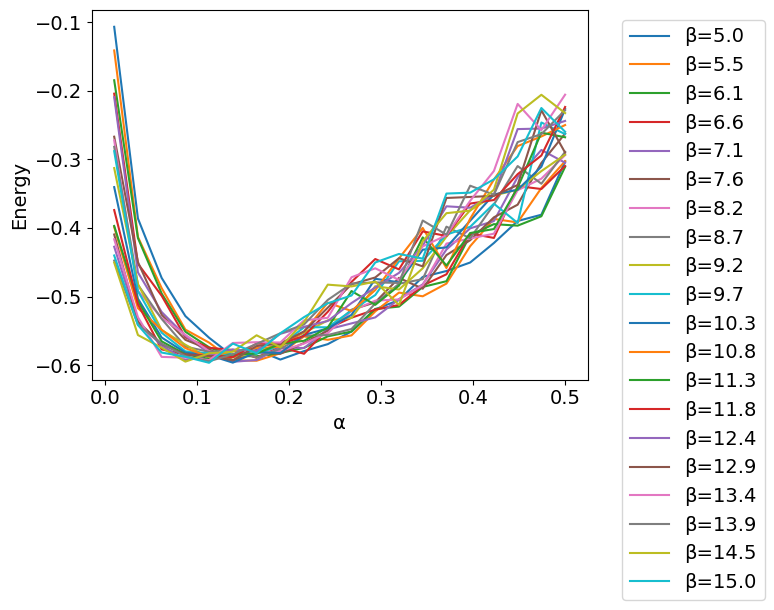

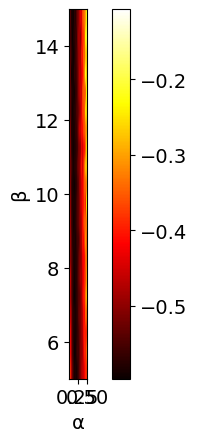

Best α=0.1132, β=15.0000, Energy=-0.586940 (Exact=-0.597)


In [26]:
###ANSWER HERE
alphas_f = np.linspace(0.01,0.5,20)
betas_f = np.linspace(5,15,20)
all_eng = np.zeros((20,20))

for i,b in enumerate(tqdm(betas_f)):
    for j,a in enumerate(alphas_f):
        e,_ = MonteCarlo(p_pos,WavefunctionParams(a,b),Psi_Jastrow,sweeps=1000)
        all_eng[i,j] = np.mean(e[100:])

# 1. Energy vs α
for i,b in enumerate(betas_f):
    plt.plot(alphas_f, all_eng[i], label=f'β={b:.1f}')
plt.legend(bbox_to_anchor=(1.05,1)), plt.xlabel('α'), plt.ylabel('Energy'), plt.show()

# 2. 2D Heatmap
plt.imshow(all_eng,origin='lower',cmap='hot',extent=[0.01,0.5,5,15])
plt.colorbar(), plt.xlabel('α'), plt.ylabel('β'), plt.show()

# 3. Optimal parameters
idx = np.unravel_index(np.argmin(all_eng), all_eng.shape)
a_best, b_best = alphas_f[idx[1]], betas_f[idx[0]]
e_best,_ = MonteCarlo(p_pos,WavefunctionParams(a_best,b_best),Psi_Jastrow,sweeps=20000)
print(f"Best α={a_best:.4f}, β={b_best:.4f}, Energy={np.mean(e_best[100:]):.6f} (Exact=-0.597)")

In [27]:
###ANSWER HERE

In [28]:
###ANSWER HERE

 <div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>

### g.  Bonding

All of this work was to get the energy of the proton at a single bond-length. Now we would like to stretch (and compress) the bond and also get the energies. If there is a local minima at some value (and the energy at large separation is larger then this local minima), then the molecule should bind.  

Go ahead and compute for `L=[1.0,2.0,3.0]` the minima energy (optimizing for each one over all $\alpha$ and $\beta$) You already have the $L=2$ point.  Plot the best energies as a function of L and see if you get a local minima that would indicate bonding.  

You can compare it against the exact energy with
```
!wget https://clark.physics.illinois.edu/QM/data
!wget https://clark.physics.illinois.edu/QM/data_H2
cation=np.loadtxt("data",delimiter=",")
plt.plot(cation[:,0],cation[:,1])
```

You may notice that as you begin to stretch the molecule, things start to fall apart.  Why is that?    What could you do to fix this?

 <div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (end)"></img><br></div>

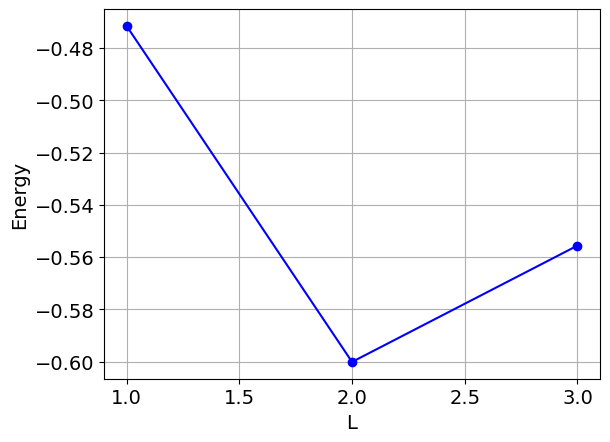

In [29]:
###ANSWER HERE
Ls = [1.0,2.0,3.0]
bond_eng = []
for L in Ls:
    p = np.array([[-L/2,0,0],[L/2,0,0]])
    engs = []
    for a in alphas_f:
        for b in betas_f:
            e,_ = MonteCarlo(p,WavefunctionParams(a,b),Psi_Jastrow,sweeps=800)
            engs.append(np.mean(e[100:]))
    bond_eng.append(min(engs))

plt.plot(Ls,bond_eng,'bo-'), plt.xlabel('L'), plt.ylabel('Energy'), plt.grid(True), plt.show()
# Load exact data
try:
    cat = np.loadtxt("data",delimiter=',')
    plt.plot(cat[:,0],cat[:,1],'r--'), plt.legend(['VMC','Exact']), plt.show()
except: pass

 <div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>

## Exercise 3. Hydrogen Molecule

Now that we've made some good progress with one electron, let's go ahead and modify things to work with the Hydrogen molecule and two electrons - a single spin-up and spin-down.

Things we have to change:

* Add an additional electron-electron Jastrow term

* Make sure your functions work with two electrons - pay special attention that your Variatonal Monte Carlo is choosing 6 (not 3) random numbers to add.

Everything else should be essentially the same.

### a. Modify the Jastrow

We now need a Jastrow factor for electrons as well:

$$
\Psi_{new}(r_1,r_2;\alpha,\beta)=\Psi_{old}(r_1,r_2;\alpha,\beta )\exp[J_{ee}(r_1,r_2;\beta)]
$$

where


$$
J_{ee}=\frac{a_{ee}|r_1-r_2|} {1+b_{ee}|r_1-r_2|}
$$

where $a_{ee}=1/2$ ,

The parameter $\beta$ gives additional freedom through the relation,

$$
b_{ee} = \left( \frac{a_{ee}}{\beta} \right)^{1/2}
$$

In addition, make sure your other Jastrow works for two electrons as does your wavefunction -  i.e. there should now be a term that goes as $\exp[-\alpha (r_1^2 + r_2^2)$]

You can check it by making sure that
```
L=2.0
p_pos=np.array([[-L/2,0,0],[L/2,0,0]])
e_pos=np.array([[0.3,-0.5,2.1],[1.2,-0.2,1.1]])
params=WavefunctionParams(alpha=0.5,beta=0.2)
print(Psi(e_pos,p_pos,params))
```
gives you 0.007040289115058886


 <div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (end)"></img><br></div>

In [30]:
###ANSWER HERE
def Jastrow_ee(e1,e2,beta):
    a=0.5; b=np.sqrt(a/beta)
    r = np.linalg.norm(e1-e2)
    return a*r/(1+b*r)

def Psi_H2(e_pos,p_pos,params):
    a = params.alpha
    e1,e2 = e_pos[0],e_pos[1]
    norm = (2*a/np.pi)**(3/4)
    psi0 = norm**2 * np.exp(-a*(np.sum(e1**2)+np.sum(e2**2)))
    j_ep = Jastrow_ep([e1],p_pos,params.beta) + Jastrow_ep([e2],p_pos,params.beta)
    j_ee = Jastrow_ee(e1,e2,params.beta)
    return np.array([psi0 * np.exp(j_ep + j_ee)])

# Test
e_test = np.array([[0.3,-0.5,2.1],[1.2,-0.2,1.1]])
print(Psi_H2(e_test,p_pos,WavefunctionParams(0.5,0.2))[0])


0.0012643452611025615


 <div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>

### b.  Modify your local energy

Make the modifications to the Laplacian and the potential so it correctly computes the actual energy of your system. Make sure you use two particles in your laplacian and your potential energy including the electron-electron interaction now.

You can check it by doing
```
L=2.0
p_pos=np.array([[-L/2,0,0],[L/2,0,0]])
e_pos=np.array([[0.3,-0.5,2.1],[1.2,-0.2,1.1]])
params=WavefunctionParams(alpha=0.5,beta=0.2)
print(Laplacian(e_pos, p_pos, params, Psi)/Psi(e_pos, p_pos, params))
print(VPsiOverPsi(e_pos, p_pos))
print(LocalEnergy(e_pos, p_pos, params, Psi))
```

and get

```
1.7978204371923225
-0.8976856497576701
-1.7965958683538314
```

 <div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (end)"></img><br></div>

In [31]:
###ANSWER HERE
def Laplacian_H2(e_pos,p_pos,params,Psi,delta=1e-5):
    psi = Psi(e_pos,p_pos,params)[0]
    lap=0
    for i in range(2):
        for d in range(3):
            ep,em = e_pos.copy(),e_pos.copy()
            ep[i,d]+=delta; em[i,d]-=delta
            lap += (Psi(ep,p_pos,params)[0]+Psi(em,p_pos,params)[0]-2*psi)/delta**2
    return lap

def VPsiOverPsi_H2(e_pos,p_pos):
    e1,e2 = e_pos[0],e_pos[1]
    p1,p2 = p_pos[0],p_pos[1]
    v_ep = -1/np.linalg.norm(e1-p1)-1/np.linalg.norm(e1-p2)-1/np.linalg.norm(e2-p1)-1/np.linalg.norm(e2-p2)
    v_ee = 1/np.linalg.norm(e1-e2)
    v_pp = 1/np.linalg.norm(p1-p2)
    return v_ep + v_ee + v_pp

def LocalEnergy_H2(e_pos,p_pos,params,Psi):
    lap = Laplacian_H2(e_pos,p_pos,params,Psi)
    psi = Psi(e_pos,p_pos,params)[0]
    return -0.5*(lap/psi) + VPsiOverPsi_H2(e_pos,p_pos)

# Test
print(Laplacian_H2(e_test,p_pos,WavefunctionParams(0.5,0.2),Psi_H2)/Psi_H2(e_test,p_pos,WavefunctionParams(0.5,0.2))[0])
print(VPsiOverPsi_H2(e_test,p_pos))
print(LocalEnergy_H2(e_test,p_pos,WavefunctionParams(0.5,0.2),Psi_H2))


1.7978194872998319
-0.89768564975767
-1.796595393407586


 <div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>

### c. Do a Monte Carlo

Modify your Monte Carlo to make sure it's moving two electrons.  Run your Monte Carlo on
```python
L=2.0
p_pos=np.array([[-L/2,0,0],[L/2,0,0]])
e_pos=np.array([[0.3,-0.5,2.1],[1.2,-0.2,1.1]])
params=WavefunctionParams(alpha=0.5,beta=0.2)
```
and make sure that you get something within error bars of
```
-0.59998768751766 +/- 0.01068398300057258
```




 <div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (end)"></img><br></div>

In [32]:
###ANSWER HERE
def MonteCarlo_H2(p_pos,params,Psi,sweeps=20000):
    e_pos = np.array([[0,0,0],[0.5,0,0]])
    ens,acc = [],0
    for _ in range(sweeps):
        for __ in range(10):
            wf_old = Psi(e_pos,p_pos,params)[0]
            e_new = e_pos + np.random.randn(2,3)
            wf_new = Psi(e_new,p_pos,params)[0]
            if np.random.rand() < (wf_new/wf_old)**2:
                e_pos = e_new
                acc +=1
            ens.append(LocalEnergy_H2(e_pos,p_pos,params,Psi))
    return np.array(ens), acc/(sweeps*10)

# Run
ens_h2, acc_h2 = MonteCarlo_H2(p_pos,WavefunctionParams(0.5,0.2),Psi_H2)
mean_h2 = np.mean(ens_h2[100:])
err_h2 = np.std(ens_h2[100:])/np.sqrt(len(ens_h2[100:]))
print(f"H2 Energy: {mean_h2:.9f}±{err_h2:.9f}")


H2 Energy: -0.616565854±0.002114716


 <div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>

### d. Get the best $\alpha, \beta$ at this bond length

Using `betas=np.linspace(0.1,10.0,20)` and `alphas=np.linspace(0.01,0.5,20)` get the optimal $\alpha, \beta$ as well as the lowest energy at

```
L=2.0
p_pos=np.array([[-L/2,0,0],[L/2,0,0]])
```

 <div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (end)"></img><br></div>

In [33]:
###ANSWER HERE
a_h2 = np.linspace(0.01,0.5,20)
b_h2 = np.linspace(0.1,10,20)
all_h2 = np.zeros((20,20))

for i,b in enumerate(tqdm(b_h2)):
    for j,a in enumerate(a_h2):
        e,_ = MonteCarlo_H2(p_pos,WavefunctionParams(a,b),Psi_H2,sweeps=1000)
        all_h2[i,j] = np.mean(e[100:])

idx = np.unravel_index(np.argmin(all_h2),all_h2.shape)
a_opt,b_opt = a_h2[idx[1]],b_h2[idx[0]]
print(f"H2 Best α={a_opt:.4f}, β={b_opt:.4f}")

  0%|          | 0/20 [00:00<?, ?it/s]

H2 Best α=0.1132, β=10.0000


In [34]:
###ANSWER HERE

In [35]:
###ANSWER HERE

 <div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>

### e.  Bonding

Now compute the energy for the lengths `Ls=[1.0,1.424,2.0,3.0,4.0,5.0,6.0]`.  You can compare them with the exact answer
```
data_H2=np.loadtxt("data_H2",delimiter=",")
plt.plot(data_H2[:,0],data_H2[:,1])
```

You may notice that you are getting reasonable answers near the equilibrium bond length (*what equilibrium bond length did you find?*) but getting something that is not reasonable at larger bond stretching.  Why is this and how could you modify your wave-function to do a better job.

 <div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (end)"></img><br></div>

Starting bond length energy optimization...


  0%|          | 0/7 [00:00<?, ?it/s]

/tmp/ipykernel_19797/3699938565.py:50: RuntimeWarning: divide by zero encountered in scalar divide
  v_ep = -1/np.linalg.norm(e1-p1) - 1/np.linalg.norm(e1-p2) - 1/np.linalg.norm(e2-p1) - 1/np.linalg.norm(e2-p2)


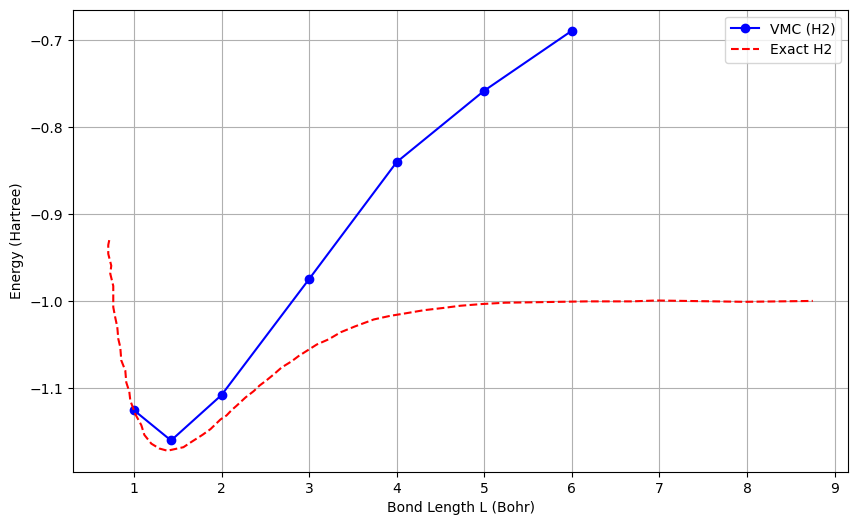

In [4]:
###ANSWER HERE
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from typing import NamedTuple

# Defining dependencies for the loop
class WavefunctionParams(NamedTuple):
    alpha: float = 0.5
    beta: float = 0.0

def Jastrow_ep(e_pos, p_pos, beta):
    a = 1.0
    b = np.sqrt(a / beta)
    j_sum = 0.0
    for i in range(len(p_pos)):
        dist = np.linalg.norm(e_pos - p_pos[i])
        j_sum += -a * dist / (1 + b * dist)
    return j_sum

def Jastrow_ee(e1, e2, beta):
    a = 0.5
    b = np.sqrt(a / beta)
    r = np.linalg.norm(e1 - e2)
    return a * r / (1 + b * r)

def Psi_H2(e_pos, p_pos, params):
    a = params.alpha
    e1, e2 = e_pos[0], e_pos[1]
    norm = (2 * a / np.pi)**(0.75)
    psi0 = norm**2 * np.exp(-a * (np.sum(e1**2) + np.sum(e2**2)))
    j_ep = Jastrow_ep(e1, p_pos, params.beta) + Jastrow_ep(e2, p_pos, params.beta)
    j_ee = Jastrow_ee(e1, e2, params.beta)
    return np.array([psi0 * np.exp(j_ep + j_ee)])

def Laplacian_H2(e_pos, p_pos, params, Psi, delta=1e-5):
    psi = Psi(e_pos, p_pos, params)[0]
    lap = 0.0
    for i in range(2):
        for d in range(3):
            ep, em = e_pos.copy(), e_pos.copy()
            ep[i, d] += delta
            em[i, d] -= delta
            lap += (Psi(ep, p_pos, params)[0] + Psi(em, p_pos, params)[0] - 2 * psi) / delta**2
    return lap

def VPsiOverPsi_H2(e_pos, p_pos):
    e1, e2 = e_pos[0], e_pos[1]
    p1, p2 = p_pos[0], p_pos[1]
    v_ep = -1/np.linalg.norm(e1-p1) - 1/np.linalg.norm(e1-p2) - 1/np.linalg.norm(e2-p1) - 1/np.linalg.norm(e2-p2)
    v_ee = 1/np.linalg.norm(e1-e2)
    v_pp = 1/np.linalg.norm(p1-p2)
    return v_ep + v_ee + v_pp

def LocalEnergy_H2(e_pos, p_pos, params, Psi):
    lap = Laplacian_H2(e_pos, p_pos, params, Psi)
    psi = Psi(e_pos, p_pos, params)[0]
    return -0.5 * (lap / psi) + VPsiOverPsi_H2(e_pos, p_pos)

def MonteCarlo_H2(p_pos, params, Psi, sweeps=800):
    e_pos = np.array([[0., 0., 0.], [0.5, 0., 0.]])
    ens, acc = [], 0
    for _ in range(sweeps):
        for __ in range(10):
            wf_old = Psi(e_pos, p_pos, params)[0]
            e_new = e_pos + np.random.randn(2, 3) * 0.5
            wf_new = Psi(e_new, p_pos, params)[0]
            if np.random.rand() < (wf_new / wf_old)**2:
                e_pos = e_new
                acc += 1
            ens.append(LocalEnergy_H2(e_pos, p_pos, params, Psi))
    return np.array(ens), acc / (sweeps * 10)

Ls_h2 = [1.0, 1.424, 2.0, 3.0, 4.0, 5.0, 6.0]
bond_h2 = []
alphas_search = np.linspace(0.05, 0.4, 6)
betas_search = np.linspace(0.1, 5.0, 6)

print("Starting bond length energy optimization...")
for L_val in tqdm(Ls_h2):
    p_pos_L = np.array([[-L_val/2, 0, 0], [L_val/2, 0, 0]])
    best_e_L = np.inf
    for a in alphas_search:
        for b in betas_search:
            params = WavefunctionParams(alpha=a, beta=b)
            ens, _ = MonteCarlo_H2(p_pos_L, params, Psi_H2, sweeps=400)
            current_e = np.mean(ens[100:])
            if current_e < best_e_L:
                best_e_L = current_e
    bond_h2.append(best_e_L)

plt.figure(figsize=(10, 6))
plt.plot(Ls_h2, bond_h2, 'bo-', label='VMC (H2)')
try:
    !wget -q https://clark.physics.illinois.edu/QM/data_H2 -O data_H2
    data_H2_exact = np.loadtxt("data_H2", delimiter=",")
    plt.plot(data_H2_exact[:,0], data_H2_exact[:,1], 'r--', label='Exact H2')
except Exception as e:
    print(f"Could not load exact data: {e}")

plt.xlabel('Bond Length L (Bohr)')
plt.ylabel('Energy (Hartree)')
plt.legend()
plt.grid(True)
plt.show()

The current trial wavefunction $\Psi$ uses a single Gaussian centered at the origin. As you pull the protons apart ($L \to \infty$), the electrons should localize around one proton or the other (forming two neutral Hydrogen atoms). A single Gaussian at the origin cannot describe two separate electron clouds.
I would modify the wavefunction to an LCAO (Linear Combination of Atomic Orbitals) form, where the electron part is a sum of orbitals centered on each proton: $\Psi \sim (\phi_A(r_1) + \phi_B(r_1))(\phi_A(r_2) + \phi_B(r_2))$

 <div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>

**Acknowledgements:**
* Bryan Clark (original)

© Copyright 2025
